In [ ]:
### This script is used to analyze the 2p data and corresponding treadmill behavior data
### 1. Load the 2p data and treadmill behavior data
### 2. Align the 2p data and treadmill behavior data
### 3. Remove any time points where the treadmill behavior data is not available
### 4. Calculate and plotthe average 2p response across all trials (treadmill behavior data)
### 5. Calculate the correlation between the 2p data and treadmill behavior data

In [1]:
cd "C:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation"

C:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation


**1. Load the 2p data and treadmill behavior data**

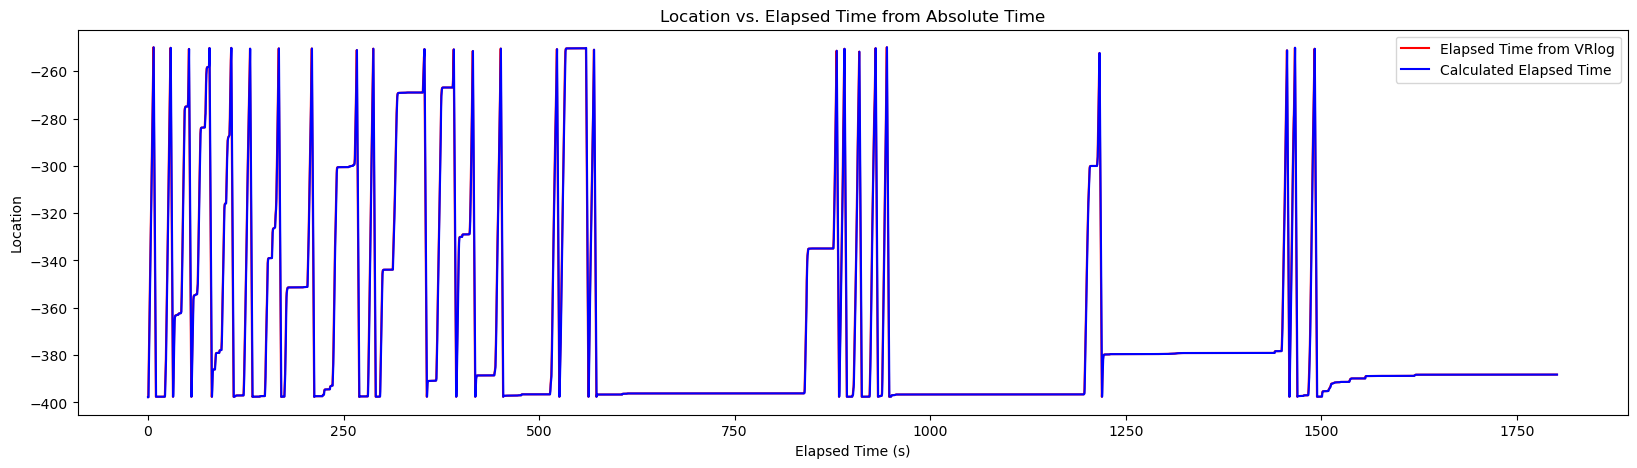

dict_keys(['absoluteT', 'elapsedT', 'event', 'location', 'calc_elapsedT'])
dict_keys(['sps', 'dFF', 'twopT'])


In [41]:
import os
import re
import datetime
import numpy as np
from helper import TwoP, read_xml, time2float
import matplotlib.pyplot as plt

# File path to VRlog.txt and 2p data
filepath = r'D:\LongitudinalImaging_Data\JSY018\RawData\240829_JSY_JSY018_LongitudinalImaging_P5\TSeries-08292024-1523_Z1-001'
VRfilepath = r"D:\V1_SpatialModulation\V1_SpatialMod_VRLog"
twoP_filename = "TSeries-01292025-1411-001"
VRlog_filename = "VRlog_JSY038_01282025_02-14-34.txt"
VRlog_path = os.path.join(VRfilepath, VRlog_filename)

# Extract animal ID and date from the VR_log_filename
match = re.match(r"VRlog_(JSY\d+)_(\d{8})_\d{2}-\d{2}-\d{2}\.txt", VRlog_filename)
if match:
    animal_id = match.group(1)
    date = match.group(2)
else:
    print("Filename format does not match the expected pattern.")

# Initialize dictionaries to store raw data
twoP_data = {}
VR_data = {}

# Load twoP data
raw_twop_data = TwoP(filepath, twoP_filename)

raw_twop_data.find_files()
twop_dict = raw_twop_data.calc_dFF()

twoP_data['sps'] = twop_dict['spikes_per_sec'].copy()
twoP_data['dFF'] = twop_dict['norm_dFF'].copy()

numFrames = np.size(twoP_data['sps'], 1)

xml_path = os.path.join(
    filepath, r"TSeries-08292024-1523_Z1-001.xml"
)
xml_dict = read_xml(xml_path)
t0 = xml_dict["t0"]
abs_time = xml_dict["abs_time"]

twopT = np.zeros(np.size(abs_time, 0) - 1, dtype=datetime.datetime)
for rep, t in enumerate(abs_time[:-1]):
    twopT[rep] = t0 + datetime.timedelta(seconds=t)

twopT_float = time2float(twopT)
twoP_data['twopT'] = twopT

# Load VRlog
rawVR_data = []
with open(VRlog_path, "r") as file:
    lines = file.readlines()
    for line in lines[3:]:
        rawVR_data.append(line.strip().split("\t"))

VR_data['absoluteT'] = np.array([line[0] for line in rawVR_data])
VR_data['elapsedT'] = np.array([float(line[1]) for line in rawVR_data])
VR_data['event'] = np.array([line[2] for line in rawVR_data])
VR_data['location'] = np.array([float(line[3]) for line in rawVR_data])

# Calculate elapsed time from absolute time
absoluteT_datetime = [datetime.datetime.strptime(t, '%H.%M.%S.%f') for t in VR_data['absoluteT']]
calc_elapsedT = [(t - absoluteT_datetime[0]).total_seconds() for t in absoluteT_datetime]
VR_data['calc_elapsedT'] = np.array(calc_elapsedT)

plt.figure(figsize=(20, 5))
plt.plot(VR_data['elapsedT'], VR_data['location'], color='r')

plt.plot(VR_data['calc_elapsedT'], VR_data['location'], color='b')
plt.xlabel('Elapsed Time (s)')
plt.ylabel('Location')
plt.title('Location vs. Elapsed Time from Absolute Time')
plt.legend(['Elapsed Time from VRlog', 'Calculated Elapsed Time'])
plt.show()

print(VR_data.keys())
print(twoP_data.keys())

**3. Align the 2p data and treadmill behavior data**

0.07991201135909838


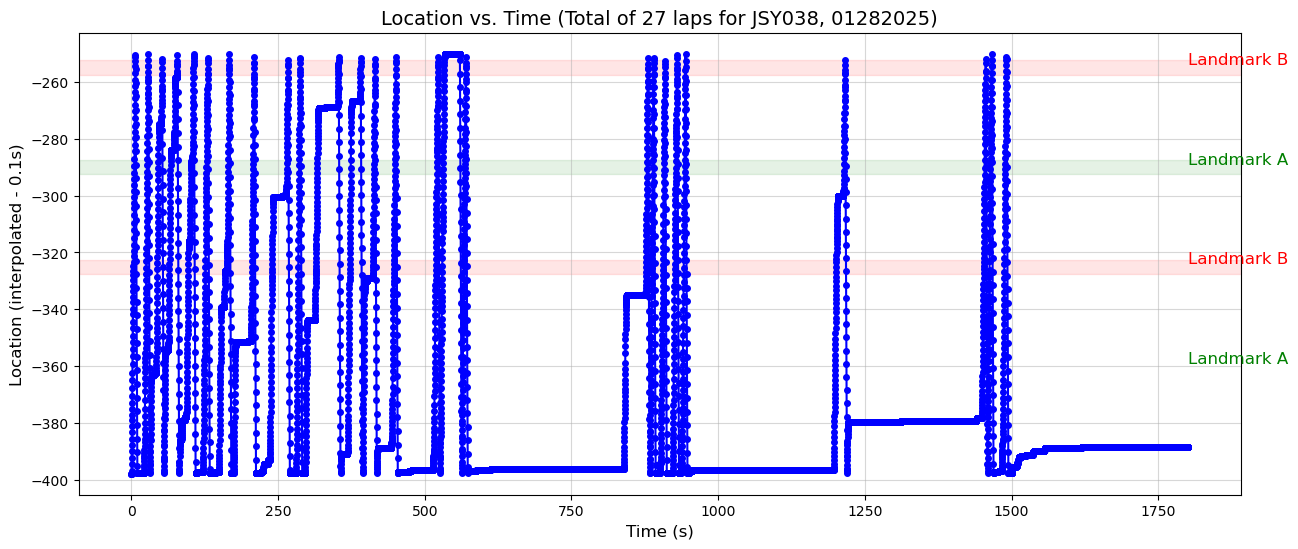

In [7]:
import matplotlib.pyplot as plt

# Extract time and location for event type 'p' -- p from the positionlogger.cs
elapsed_time = []
elapsed_location = []

for entry in VR_data:
    if (
        len(entry) >= 3 and entry[2] == "p"
    ):  # Ensure the row has enough columns and the second column is 'p'
        try:
            elapsed_time.append(float(entry[1]))  # Convert elapsed time to float
            elapsed_location.append(float(entry[3]))  # Convert location to float
        except ValueError:
            # Skip rows where conversion fails
            continue

# calculate the number of laps (number of "n" event in the third column of rawVR_data)
num_laps = sum([1 for entry in VR_data if len(entry) >= 3 and entry[2] == "n"])

# calculate the average increment of time -- framerate of VR log
time_increment = np.diff(elapsed_time)
average_increment = np.mean(time_increment)
print(average_increment)

# interpolate the location data for every 0.1 s -- to match the framerate of 2p data
time_interp = np.arange(elapsed_time[0], elapsed_time[-1], 0.1)
location_interp = np.interp(time_interp, elapsed_time, elapsed_location)

# Plot location vs. time
plt.figure(figsize=(15, 6))
plt.plot(
    time_interp, location_interp, marker="o", linestyle="-", color="b", markersize=4
)
plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("Location (interpolated - 0.1s)", fontsize=12)
plt.title(
    f"Location vs. Time (Total of {num_laps} laps for {animal_id}, {date})", fontsize=14
)
plt.axhspan(-292.5, -287.5, color="green", alpha=0.1)
plt.text(
    time_interp[-1],
    -360,
    "Landmark A",
    color="green",
    fontsize=12,
    verticalalignment="bottom",
    horizontalalignment="left",
)
plt.text(
    time_interp[-1],
    -290,
    "Landmark A",
    color="green",
    fontsize=12,
    verticalalignment="bottom",
    horizontalalignment="left",
)

plt.axhspan(-327.5, -322.5, color="red", alpha=0.1)
plt.axhspan(-257.5, -252.5, color="red", alpha=0.1)
plt.text(
    time_interp[-1],
    -325,
    "Landmark B",
    color="red",
    fontsize=12,
    verticalalignment="bottom",
    horizontalalignment="left",
)
plt.text(
    time_interp[-1],
    -255,
    "Landmark B",
    color="red",
    fontsize=12,
    verticalalignment="bottom",
    horizontalalignment="left",
)

plt.grid(alpha=0.5)
plt.show()

**4. Remove any time points where the treadmill behavior data is not available**

**5. Calculate and plotthe average 2p response across all trials (treadmill behavior data)**

**6. Calculate the correlation between the 2p data and treadmill behavior data**